In [3]:
!pip install keras
!pip install tensorflow


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Activation
# other imports as needed


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Activation
# from keras.callbacks import TensorBoard, ModelCheckpoint, ReduceLROnPlateau
import datetime

C:\Users\eugen\Downloads


In [5]:
import os
print(os.getcwd())
os.chdir('C:/Users/eugen/')

In [6]:
# Load dataset
data_qqq = pd.read_csv('dataset/QQQ.csv')

In [7]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [8]:
data_qqq.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-02-19,90.080002,90.290001,89.449997,89.629997,82.181267,41749900
1,2014-02-20,89.690002,90.220001,89.309998,90.050003,82.566376,41814800
2,2014-02-21,90.339996,90.470001,89.820000,89.930000,82.456345,31192200
3,2014-02-24,90.139999,90.820000,90.040001,90.410004,82.896423,31500400
4,2014-02-25,90.540001,90.720001,90.019997,90.309998,82.804726,26771700


In [9]:

len(data_qqq)

2517

In [10]:
data_vix = pd.read_csv('dataset/vix.csv')

In [11]:
data_vix.head()
len(data_vix)

2608

In [12]:
merged_data = pd.merge(data_qqq, data_vix, on='Date', how='inner')

In [13]:
data=merged_data

In [14]:
data.head()

,Date,Open_x,High_x,Low_x,Close_x,Adj Close_x,Volume_x,Open_y,High_y,Low_y,Close_y,Adj Close_y,Volume_y
0,2014-02-19,90.080002,90.290001,89.449997,89.629997,82.181267,41749900,14.85,15.73,14.12,15.50,15.50,0.0
1,2014-02-20,89.690002,90.220001,89.309998,90.050003,82.566376,41814800,15.28,15.80,14.59,14.79,14.79,0.0
2,2014-02-21,90.339996,90.470001,89.820000,89.930000,82.456345,31192200,14.74,14.79,14.19,14.68,14.68,0.0
3,2014-02-24,90.139999,90.820000,90.040001,90.410004,82.896423,31500400,14.83,14.83,13.97,14.23,14.23,0.0
4,2014-02-25,90.540001,90.720001,90.019997,90.309998,82.804726,26771700,14.17,14.83,13.66,13.67,13.67,0.0


In [15]:
# Calculate mean price for qqq
high_prices = data['High_x'].values
low_prices = data['Low_x'].values
mid_prices = (high_prices + low_prices) / 2

In [16]:
# Use VIX and Volume
high_VIX = data['High_y'].values
low_VIX = data['Low_y'].values

vix = (high_prices + low_prices) / 2
volumes = data['Volume_x'].values

In [17]:
# Combine all features into one matrix
features = np.column_stack((mid_prices, vix, volumes))

In [18]:
# Normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(features)



In [19]:
# Prepare the dataset for training
seq_len = 50
result = []
for index in range(len(scaled_features) - seq_len):
    result.append(scaled_features[index: index + seq_len + 1])

result = np.array(result)

In [20]:
# Split train and test data
row = int(round(0.9 * result.shape[0]))
train = result[:row, :]
np.random.shuffle(train)

x_train = train[:, :-1]
y_train = train[:, -1][:,1]  # Assuming the second feature is the closing price you want to predict

x_test = result[row:, :-1]
y_test = result[row:, -1][:,1]

# Reshape data for LSTM layer
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 3))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 3))


In [21]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_len, 3)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(1, activation='linear'))

model.compile(loss='mse', optimizer='rmsprop')
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50, 50)            10800     
                                                                 
 lstm_1 (LSTM)               (None, 64)                29440     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 40305 (157.44 KB)
Trainable params: 40305 (157.44 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
# Train the model
model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=10, epochs=20)



Epoch 1/20

222/222 [==============================] - 6s 15ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 2/20
222/222 [==============================] - 3s 13ms/step - loss: 8.2762e-04 - val_loss: 0.0031
Epoch 3/20
222/222 [==============================] - 3s 14ms/step - loss: 6.4628e-04 - val_loss: 5.5789e-04
Epoch 4/20
222/222 [==============================] - 3s 12ms/step - loss: 5.2982e-04 - val_loss: 3.7800e-04
Epoch 5/20
222/222 [==============================] - 3s 12ms/step - loss: 4.6872e-04 - val_loss: 0.0084
Epoch 6/20
222/222 [==============================] - 3s 12ms/step - loss: 4.3183e-04 - val_loss: 0.0049
Epoch 7/20
222/222 [==============================] - 3s 12ms/step - loss: 3.7903e-04 - val_loss: 5.9623e-04
Epoch 8/20
222/222 [==============================] - 3s 12ms/step - loss: 3.6741e-04 - val_loss: 3.5487e-04
Epoch 9/20
222/222 [==============================] - 3s 15ms/step - loss: 3.3513e-04 - val_loss: 0.0016
Epoch 10/20
222/222 [=====================

In [23]:
# Make predictions
pred = model.predict(x_test)



8/8 [==============================] - 1s 7ms/step


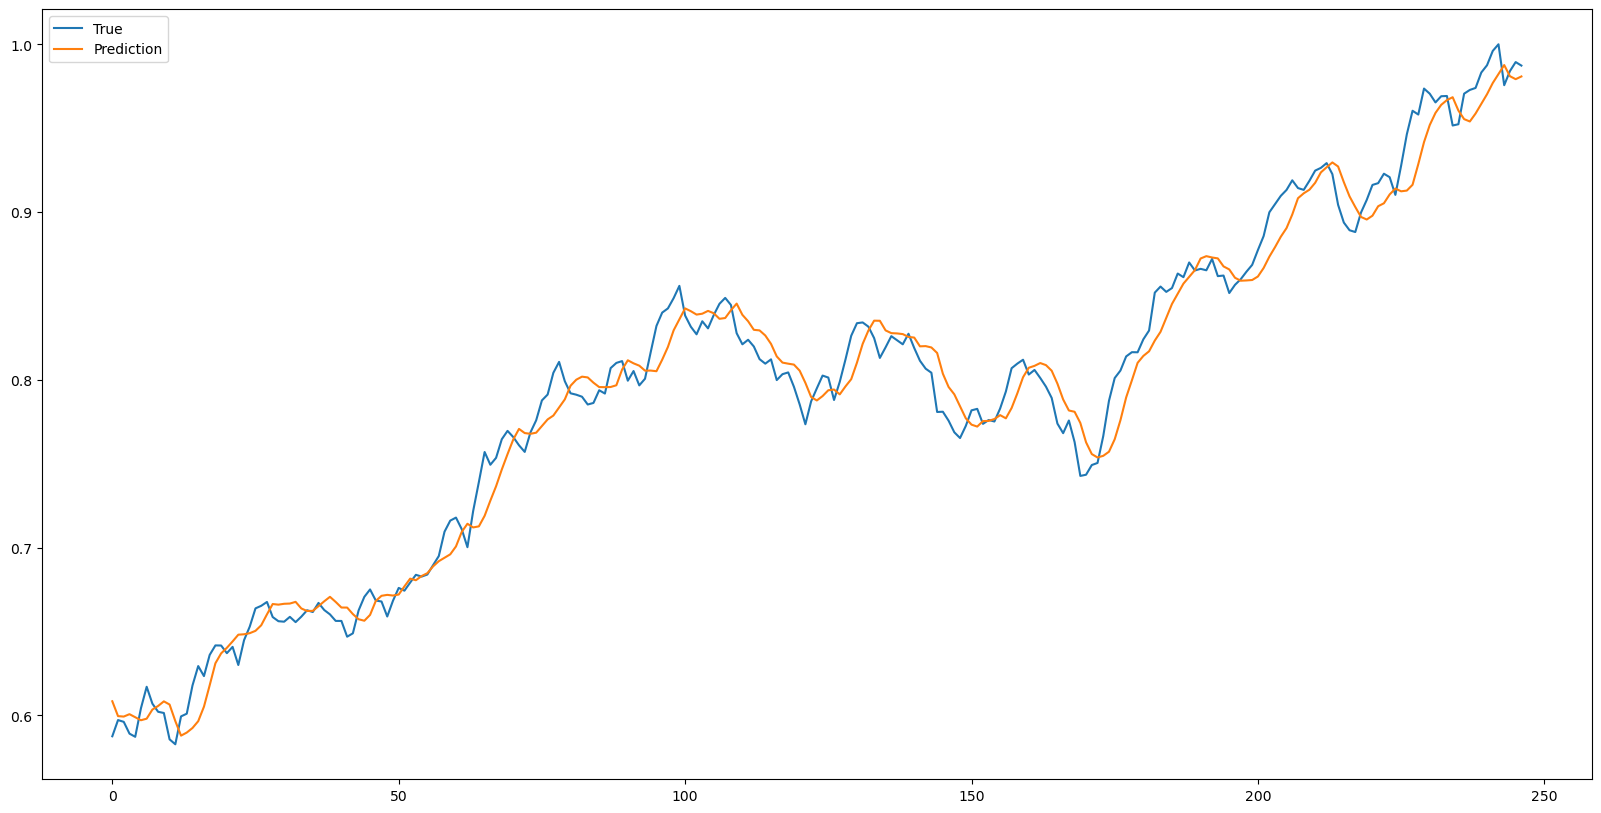

In [29]:
# Plotting
plt.figure(figsize=(20, 10))
plt.plot(y_test, label='True')
plt.plot(pred, label='Prediction')
plt.legend()
plt.show()

1